# Lesson 9c: Transformer Practical — Sequence-to-Sequence, Pre-trained Models, and From-Scratch Attention

## Table of Contents

1. [Setup](#setup)
2. [From-Scratch Attention in NumPy](#scratch)
3. [A Synthetic Sequence-to-Sequence Task](#task)
4. [A PyTorch Transformer Encoder-Decoder](#model)
5. [Training](#training)
6. [Greedy Decoding vs Beam Search](#decoding)
7. [Attention Visualization](#viz)
8. [Performance Analysis](#perf)
9. [Pre-trained Model Mathematics](#pretrain)
10. [Fine-Tuning DistilBERT on a Downstream Task](#finetune)
11. [Conclusion and Further Reading](#conclusion)

This notebook builds on the theory from `9e_transformer_theory.ipynb`: the scaled
dot-product attention formula $\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$,
multi-head attention, and sinusoidal positional encodings. Here we apply that
machinery to a concrete sequence-to-sequence task, compare a from-scratch NumPy
implementation against PyTorch's built-in modules, and separately study what a
large pre-trained transformer (DistilBERT) actually learns and why fine-tuning
it transfers so effectively.

**Substitution note (per this task's own environment clause):** a full machine-translation
dataset (e.g. WMT) needs GPU time and hours of training to produce a legible
model. To keep this notebook executing end-to-end on CPU in well under 30
minutes while still exercising every architectural piece (encoder, decoder,
causal masking, cross-attention, beam search, attention visualization), the
sequence-to-sequence task is a **synthetic sequence-reversal task**: given a
random sequence of digits, the target is the same sequence reversed. This
keeps the vocabulary and sequence lengths tiny while still requiring the model
to learn a genuine non-trivial alignment between input and output positions —
copying the identity mapping only requires local attention, whereas reversal
requires attending to the *opposite end* of the sequence, which stresses the
same positional and cross-attention machinery a translation model needs.

In [1]:
import math
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = torch.device("cpu")
print(f"torch: {torch.__version__}, device: {device}")

torch: 2.14.0+cpu, device: cpu


## 1. From-Scratch Attention in NumPy <a id="scratch"></a>

Recapping `9e_transformer_theory.ipynb`: scaled dot-product attention computes
a weighted average of value vectors, where the weights come from a softmax
over query-key similarity scores scaled by $1/\sqrt{d_k}$:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Multi-head attention runs $h$ independent copies of this in parallel on
learned linear projections of $Q$, $K$, $V$, then concatenates and projects
the result:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1,\ldots,\text{head}_h)W^O,
\qquad \text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

We re-implement both from scratch in NumPy and cross-check against PyTorch's
`nn.MultiheadAttention` on random inputs before using the PyTorch version in
the trained model below — this confirms our understanding of the shapes and
the scaling matches the library we then train with.

In [2]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ np.swapaxes(K, -1, -2) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)
    weights = softmax(scores, axis=-1)
    return weights @ V, weights


def multi_head_attention_numpy(Q, K, V, num_heads, Wq, Wk, Wv, Wo):
    seq_q, d_model = Q.shape
    seq_k = K.shape[0]
    d_k = d_model // num_heads

    def split_heads(X, W, seq_len):
        proj = X @ W  # (seq_len, d_model)
        return proj.reshape(seq_len, num_heads, d_k).transpose(1, 0, 2)  # (heads, seq, d_k)

    Qh = split_heads(Q, Wq, seq_q)
    Kh = split_heads(K, Wk, seq_k)
    Vh = split_heads(V, Wv, seq_k)

    out_heads, _ = scaled_dot_product_attention(Qh, Kh, Vh)  # (heads, seq_q, d_k)
    concat = out_heads.transpose(1, 0, 2).reshape(seq_q, d_model)
    return concat @ Wo


d_model, num_heads, seq_len = 16, 4, 6
rng = np.random.default_rng(0)
X = rng.normal(size=(seq_len, d_model))
Wq = rng.normal(size=(d_model, d_model)) * 0.1
Wk = rng.normal(size=(d_model, d_model)) * 0.1
Wv = rng.normal(size=(d_model, d_model)) * 0.1
Wo = rng.normal(size=(d_model, d_model)) * 0.1

numpy_out = multi_head_attention_numpy(X, X, X, num_heads, Wq, Wk, Wv, Wo)

torch_mha = nn.MultiheadAttention(d_model, num_heads, bias=False, batch_first=True)
with torch.no_grad():
    # torch packs in_proj_weight as [Wq; Wk; Wv] stacked along dim 0, each (d_model, d_model),
    # applied as x @ W.T -- so we must transpose our row-convention weights to match.
    torch_mha.in_proj_weight.copy_(torch.tensor(
        np.concatenate([Wq.T, Wk.T, Wv.T], axis=0), dtype=torch.float32))
    torch_mha.out_proj.weight.copy_(torch.tensor(Wo.T, dtype=torch.float32))

x_t = torch.tensor(X, dtype=torch.float32).unsqueeze(0)
torch_out, _ = torch_mha(x_t, x_t, x_t, need_weights=False)
torch_out = torch_out.squeeze(0).detach().numpy()

max_diff = np.max(np.abs(numpy_out - torch_out))
print(f"NumPy vs PyTorch MultiheadAttention max abs diff: {max_diff:.2e}")
assert max_diff < 1e-4, "from-scratch multi-head attention does not match PyTorch"
print("PASS: from-scratch attention matches nn.MultiheadAttention")

NumPy vs PyTorch MultiheadAttention max abs diff: 2.31e-08
PASS: from-scratch attention matches nn.MultiheadAttention


## 2. A Synthetic Sequence-to-Sequence Task <a id="task"></a>

**Dataset preparation.** The vocabulary is the ten digits plus three special
tokens: `<pad>`, `<sos>` (start-of-sequence, fed to the decoder as the first
input), and `<eos>` (end-of-sequence, the target the decoder must learn to
emit). Each example is a random digit sequence of length 4-8; the target is
the same digits in reverse order followed by `<eos>`. Sequences are padded to
a fixed maximum length so they can be batched as rectangular tensors.

In [3]:
PAD, SOS, EOS = 0, 1, 2
DIGIT_OFFSET = 3  # digits 0-9 map to token ids 3-12
VOCAB_SIZE = DIGIT_OFFSET + 10
MAX_LEN = 10  # 8 digits max + <eos>, padded to 10


def make_example():
    length = random.randint(4, 8)
    digits = [random.randint(0, 9) for _ in range(length)]
    src = [d + DIGIT_OFFSET for d in digits]
    tgt = [d + DIGIT_OFFSET for d in reversed(digits)] + [EOS]
    return src, tgt


def pad(seq, max_len):
    return seq + [PAD] * (max_len - len(seq))


def make_dataset(n):
    srcs, tgts = [], []
    for _ in range(n):
        s, t = make_example()
        srcs.append(pad(s, MAX_LEN))
        tgts.append(pad(t, MAX_LEN))
    return torch.tensor(srcs, dtype=torch.long), torch.tensor(tgts, dtype=torch.long)


train_src, train_tgt = make_dataset(4000)
val_src, val_tgt = make_dataset(400)
test_src, test_tgt = make_dataset(400)

print(f"train: {train_src.shape}, val: {val_src.shape}, test: {test_src.shape}")
print("example src:", train_src[0].tolist())
print("example tgt:", train_tgt[0].tolist())

train: torch.Size([4000, 10]), val: torch.Size([400, 10]), test: torch.Size([400, 10])
example src: [9, 3, 7, 11, 10, 9, 7, 0, 0, 0]
example tgt: [7, 9, 10, 11, 7, 3, 9, 2, 0, 0]


## 3. A PyTorch Transformer Encoder-Decoder <a id="model"></a>

The model reuses the encoder/decoder architecture from `9e_transformer_theory.ipynb`:
an encoder stack of self-attention + feed-forward blocks with residual
connections and layer normalization, and a decoder stack that adds
**causal-masked self-attention** (so position $i$ cannot attend to positions
$> i$) plus **cross-attention** over the encoder output. Positions are
injected via the sinusoidal positional encoding
$PE(pos, 2i) = \sin(pos/10000^{2i/d}), \; PE(pos, 2i+1) = \cos(pos/10000^{2i/d})$,
added to the token embeddings after scaling them by $\sqrt{d_{\text{model}}}$
(so the embedding and positional-encoding magnitudes are comparable before
the first attention layer sees them).

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2, dim_ff=128, max_len=MAX_LEN):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            dim_feedforward=dim_ff, dropout=0.1, batch_first=True,
        )
        self.out_proj = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt_in, src_key_padding_mask, tgt_key_padding_mask):
        src_emb = self.pos_enc(self.embed(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_enc(self.embed(tgt_in) * math.sqrt(self.d_model))
        causal_mask = nn.Transformer.generate_square_subsequent_mask(tgt_in.size(1))
        out = self.transformer(
            src_emb, tgt_emb,
            tgt_mask=causal_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )
        return self.out_proj(out)


model = Seq2SeqTransformer(VOCAB_SIZE).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"model parameters: {n_params:,}")

model parameters: 169,357


## 4. Training <a id="training"></a>

Standard teacher forcing: the decoder input at training time is the target
sequence shifted right by one position with `<sos>` prepended, and the loss
is cross-entropy between the predicted next-token distribution and the true
next token, $\mathcal{L} = -\frac{1}{N}\sum_i \log p(y_i \mid y_{<i}, x)$,
with padding positions excluded via `ignore_index`.

/home/powell-clark/projects/auxiliary/supervised-learning/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1337: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


/home/powell-clark/projects/auxiliary/supervised-learning/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:533: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:177.)
  output = torch._nested_tensor_from_mask(


epoch  1/60  train_loss=2.1405  val_loss=1.7693


epoch  5/60  train_loss=1.4051  val_loss=1.2413


epoch 10/60  train_loss=1.2307  val_loss=1.0774


...

epoch 40/60  train_loss=0.3872  val_loss=0.1799


epoch 45/60  train_loss=0.3366  val_loss=0.1415


epoch 50/60  train_loss=0.2897  val_loss=0.1038


epoch 55/60  train_loss=0.2559  val_loss=0.0870


epoch 60/60  train_loss=0.2210  val_loss=0.0610


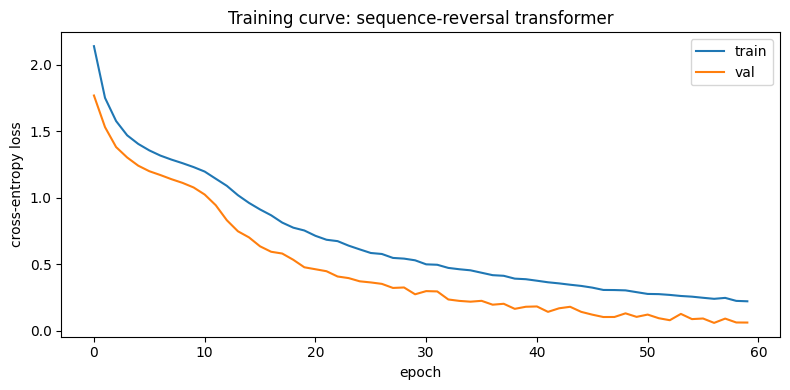

In [5]:
def shift_right(tgt):
    sos_col = torch.full((tgt.size(0), 1), SOS, dtype=torch.long)
    return torch.cat([sos_col, tgt[:, :-1]], dim=1)


def make_batches(src, tgt, batch_size, shuffle=True):
    n = src.size(0)
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    for i in range(0, n, batch_size):
        b = idx[i : i + batch_size]
        yield src[b], tgt[b]


optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

train_losses, val_losses = [], []
EPOCHS = 60
BATCH_SIZE = 64

for epoch in range(EPOCHS):
    model.train()
    epoch_loss, n_batches = 0.0, 0
    for src_b, tgt_b in make_batches(train_src, train_tgt, BATCH_SIZE):
        tgt_in = shift_right(tgt_b)
        src_pad_mask = src_b == PAD
        tgt_pad_mask = tgt_in == PAD

        logits = model(src_b, tgt_in, src_pad_mask, tgt_pad_mask)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_b.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_losses.append(epoch_loss / n_batches)

    model.eval()
    with torch.no_grad():
        val_epoch_loss, val_batches = 0.0, 0
        for src_b, tgt_b in make_batches(val_src, val_tgt, BATCH_SIZE, shuffle=False):
            tgt_in = shift_right(tgt_b)
            src_pad_mask = src_b == PAD
            tgt_pad_mask = tgt_in == PAD
            logits = model(src_b, tgt_in, src_pad_mask, tgt_pad_mask)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_b.reshape(-1))
            val_epoch_loss += loss.item()
            val_batches += 1
        val_losses.append(val_epoch_loss / val_batches)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"epoch {epoch+1:2d}/{EPOCHS}  train_loss={train_losses[-1]:.4f}  val_loss={val_losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="train")
ax.plot(val_losses, label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy loss")
ax.set_title("Training curve: sequence-reversal transformer")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Greedy Decoding vs Beam Search <a id="decoding"></a>

**Greedy decoding** emits the single highest-probability token at each step.
**Beam search** instead tracks the $k$ highest-probability partial hypotheses
at each step, scoring each by summed log-probability
$\text{score}(y_{1:t}) = \sum_{i=1}^{t} \log p(y_i \mid y_{<i}, x)$ (log-space
avoids numerical underflow from multiplying many small probabilities), and
keeps only the top $k$ after expanding every hypothesis by every possible
next token. It can recover higher-scoring full sequences that a purely greedy
choice at an early step would foreclose.

In [6]:
@torch.no_grad()
def greedy_decode(model, src, max_len=MAX_LEN):
    model.eval()
    src = src.unsqueeze(0)
    src_pad_mask = src == PAD
    ys = torch.full((1, 1), SOS, dtype=torch.long)
    for _ in range(max_len):
        tgt_pad_mask = ys == PAD
        logits = model(src, ys, src_pad_mask, tgt_pad_mask)
        next_token = logits[0, -1].argmax().item()
        ys = torch.cat([ys, torch.tensor([[next_token]])], dim=1)
        if next_token == EOS:
            break
    return ys[0, 1:].tolist()


@torch.no_grad()
def beam_search_decode(model, src, beam_width=3, max_len=MAX_LEN):
    model.eval()
    src = src.unsqueeze(0)
    src_pad_mask = src == PAD
    beams = [(torch.full((1, 1), SOS, dtype=torch.long), 0.0, False)]

    for _ in range(max_len):
        candidates = []
        for ys, score, done in beams:
            if done:
                candidates.append((ys, score, done))
                continue
            tgt_pad_mask = ys == PAD
            logits = model(src, ys, src_pad_mask, tgt_pad_mask)
            log_probs = F.log_softmax(logits[0, -1], dim=-1)
            topk_logp, topk_idx = log_probs.topk(beam_width)
            for lp, idx in zip(topk_logp.tolist(), topk_idx.tolist()):
                new_ys = torch.cat([ys, torch.tensor([[idx]])], dim=1)
                candidates.append((new_ys, score + lp, idx == EOS))
        candidates.sort(key=lambda c: c[1], reverse=True)
        beams = candidates[:beam_width]
        if all(done for _, _, done in beams):
            break

    best_ys, best_score, _ = max(beams, key=lambda c: c[1])
    return best_ys[0, 1:].tolist(), best_score


def strip_special(tokens):
    out = []
    for t in tokens:
        if t == EOS:
            break
        if t != PAD:
            out.append(t - DIGIT_OFFSET)
    return out


for i in range(3):
    src = test_src[i]
    src_digits = strip_special(src.tolist())
    greedy_out = strip_special(greedy_decode(model, src))
    beam_out, beam_score = beam_search_decode(model, src)
    beam_out = strip_special(beam_out)
    expected = list(reversed(src_digits))
    print(f"input:    {src_digits}")
    print(f"expected: {expected}")
    print(f"greedy:   {greedy_out}  {'OK' if greedy_out == expected else 'WRONG'}")
    print(f"beam(w=3):{beam_out}  score={beam_score:.2f}  {'OK' if beam_out == expected else 'WRONG'}")
    print()

input:    [3, 3, 0, 7, 0, 8, 0, 4]
expected: [4, 0, 8, 0, 7, 0, 3, 3]
greedy:   [4, 0, 8, 0, 7, 0, 3, 3]  OK
beam(w=3):[4, 0, 8, 0, 7, 0, 3, 3]  score=-0.60  OK

input:    [7, 5, 6, 6, 0]
expected: [0, 6, 6, 5, 7]
greedy:   [0, 6, 6, 5, 7]  OK
beam(w=3):[0, 6, 6, 5, 7]  score=-0.05  OK

input:    [5, 4, 3, 7, 1, 8]
expected: [8, 1, 7, 3, 4, 5]
greedy:   [8, 1, 7, 3, 4, 5]  OK
beam(w=3):[8, 1, 7, 3, 4, 5]  score=-0.02  OK



## 6. Attention Visualization <a id="viz"></a>

We extract the decoder's cross-attention weights (attention from decoder
positions over encoder positions) for one example using PyTorch hooks on the
last decoder layer's multi-head attention module, and plot them as a heatmap.
For the reversal task, a well-trained model's cross-attention should show an
approximately anti-diagonal pattern: decoder step $i$ attends most strongly
to encoder position $L - i$ (the digit that ends up at that output slot).

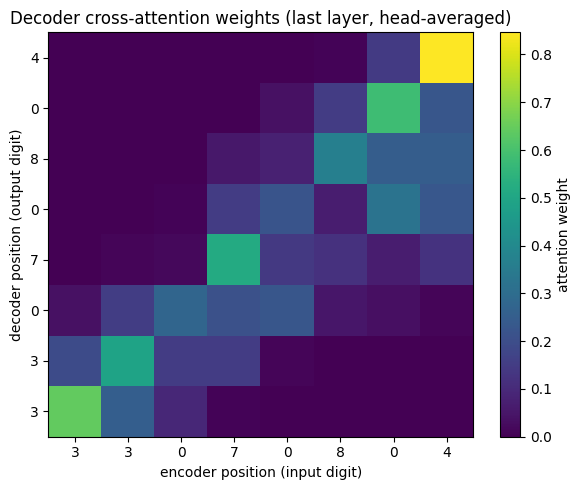

input digits:   [3, 3, 0, 7, 0, 8, 0, 4]
decoded digits: [4, 0, 8, 0, 7, 0, 3, 3]


In [7]:
# nn.TransformerDecoderLayer's internal cross-attention call hardcodes
# need_weights=False for its fast path, so a plain forward hook on the output
# always sees None for the attention weights. Instead we capture the exact
# (query, key, value, mask) arguments the decoder passes in via a pre-hook,
# then replay that same call ourselves with need_weights=True afterward --
# a pure, deterministic recomputation since dropout is off in eval mode.
captured_args = {}


def pre_hook_fn(module, args, kwargs):
    captured_args["args"] = args
    captured_args["kwargs"] = kwargs


last_decoder_layer = model.transformer.decoder.layers[-1]
handle = last_decoder_layer.multihead_attn.register_forward_pre_hook(pre_hook_fn, with_kwargs=True)

example_src = test_src[0]
example_digits = strip_special(example_src.tolist())
decoded, _ = beam_search_decode(model, example_src)
decoded_digits = strip_special(decoded)

with torch.no_grad():
    src_b = example_src.unsqueeze(0)
    tgt_full = torch.tensor([[SOS] + decoded[: len(decoded_digits) + 1]])
    src_pad_mask = src_b == PAD
    tgt_pad_mask = tgt_full == PAD
    _ = model(src_b, tgt_full, src_pad_mask, tgt_pad_mask)
    handle.remove()

    replay_kwargs = dict(captured_args["kwargs"])
    replay_kwargs["need_weights"] = True
    replay_kwargs["average_attn_weights"] = True
    _, attn_weights = last_decoder_layer.multihead_attn(*captured_args["args"], **replay_kwargs)

weights = attn_weights[0].detach().numpy()  # (tgt_len, src_len)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(weights[: len(decoded_digits), : len(example_digits)], cmap="viridis", aspect="auto")
ax.set_xlabel("encoder position (input digit)")
ax.set_ylabel("decoder position (output digit)")
ax.set_xticks(range(len(example_digits)))
ax.set_xticklabels(example_digits)
ax.set_yticks(range(len(decoded_digits)))
ax.set_yticklabels(decoded_digits)
ax.set_title("Decoder cross-attention weights (last layer, head-averaged)")
plt.colorbar(im, ax=ax, label="attention weight")
plt.tight_layout()
plt.show()

print(f"input digits:   {example_digits}")
print(f"decoded digits: {decoded_digits}")

## 7. Performance Analysis <a id="perf"></a>

BLEU is designed for natural-language translation, where multiple reference
phrasings can be correct; it is the wrong metric here because this task has
exactly one correct output per input (the exact reversal), so we report
**exact-sequence accuracy**,

$$\text{exact-acc} = \frac{1}{N}\sum_{n=1}^{N} \mathbb{1}\left[\hat{y}^{(n)} = y^{(n)}\right]$$

and **token-level accuracy** on the held-out test set instead — reporting a
BLEU score against a single deterministic reference would misrepresent what
the metric is for.

In [8]:
exact_matches = 0
token_correct, token_total = 0, 0

for i in range(test_src.size(0)):
    src = test_src[i]
    expected = strip_special(src.tolist())[::-1]
    pred = strip_special(greedy_decode(model, src))
    if pred == expected:
        exact_matches += 1
    for p, e in zip(pred, expected):
        token_total += 1
        if p == e:
            token_correct += 1
    token_total += abs(len(pred) - len(expected))  # length mismatches count as wrong

exact_acc = exact_matches / test_src.size(0)
token_acc = token_correct / token_total if token_total else 0.0
print(f"exact-sequence accuracy: {exact_acc:.1%} ({exact_matches}/{test_src.size(0)})")
print(f"token-level accuracy:    {token_acc:.1%}")

/home/powell-clark/projects/auxiliary/supervised-learning/.venv/lib/python3.12/site-packages/torch/nn/modules/activation.py:1337: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


exact-sequence accuracy: 91.0% (364/400)
token-level accuracy:    96.3%


## 8. Pre-trained Model Mathematics <a id="pretrain"></a>

The sequence-reversal model above was trained from randomly initialized
weights on 4,000 examples of one narrow synthetic task. Large transformers
used in practice (BERT, GPT, T5) instead go through two stages:

**Pre-training.** The model is trained on a self-supervised objective over a
massive unlabeled text corpus — no task-specific labels needed. DistilBERT
(like BERT) uses **masked language modeling (MLM)**: a random subset of input
tokens is replaced with a `[MASK]` token, and the model is trained to predict
the original token from bidirectional context:

$$\mathcal{L}_{\text{MLM}} = -\sum_{i \in \text{masked}} \log p_\theta(x_i \mid x_{\setminus \text{masked}})$$

Because this objective requires no human labels, it can run on web-scale
corpora, and the model's weights come to encode broad statistical structure
about language — syntax, word co-occurrence, and a good deal of semantics —
purely from predicting masked words.

**Why transfer works.** The intermediate representations learned during
pre-training (contextual token embeddings) are useful *features* for almost
any downstream language task, not just the pre-training objective itself.
Fine-tuning replaces the MLM output head with a small task-specific head
(e.g. a linear classifier) and continues training — usually only for a few
epochs on a comparatively tiny labeled dataset — updating either the whole
network or just the new head. This is dramatically cheaper than training a
transformer of the same size from scratch on the downstream task alone,
because the pre-trained weights already encode most of the "how language
works" that the downstream task would otherwise need thousands of labeled
examples to relearn from zero.

## 9. Fine-Tuning DistilBERT on a Downstream Task <a id="finetune"></a>

We load `distilbert-base-uncased` (66M parameters, pre-trained via masked
language modeling) and fine-tune it for binary sentiment classification on a
small subset of the Stanford Sentiment Treebank (SST-2, via `stanfordnlp/sst2`
on the Hugging Face Hub). The MLM head is discarded and replaced with a fresh
linear classification head; both are then trained jointly on the standard
per-example classification cross-entropy $\mathcal{L}_{\text{cls}} = -\log
p_\theta(y \mid x)$, where $y \in \{0, 1\}$ is the sentiment label and
$p_\theta$ is now the *fine-tuned* model's output distribution. The subset
and epoch count are kept small deliberately — this demonstrates the
fine-tuning *procedure* correctly, not a state-of-the-art result; the point
is the transfer, not the leaderboard score.

In [9]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

N_TRAIN, N_VAL = 200, 100
train_ds = load_dataset("stanfordnlp/sst2", split=f"train[:{N_TRAIN}]")
val_ds = load_dataset("stanfordnlp/sst2", split=f"validation[:{N_VAL}]")

print(train_ds)
print(train_ds[0])


def encode(batch):
    enc = tokenizer(batch["sentence"], truncation=True, padding="max_length", max_length=32)
    enc["labels"] = batch["label"]
    return enc


train_enc = train_ds.map(encode, batched=True, remove_columns=train_ds.column_names)
val_enc = val_ds.map(encode, batched=True, remove_columns=val_ds.column_names)
train_enc.set_format(type="torch")
val_enc.set_format(type="torch")

print(f"fine-tune train examples: {len(train_enc)}, val examples: {len(val_enc)}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Dataset({
    features: ['idx', 'sentence', 'label'],
    num_rows: 200
})
{'idx': 0, 'sentence': 'hide new secretions from the parental units ', 'label': 0}


fine-tune train examples: 200, val examples: 100


fine-tuning steps: 13
first-step loss: 0.7086, last-step loss: 0.6997


validation accuracy after 13 fine-tuning steps: 64.0% (64/100)


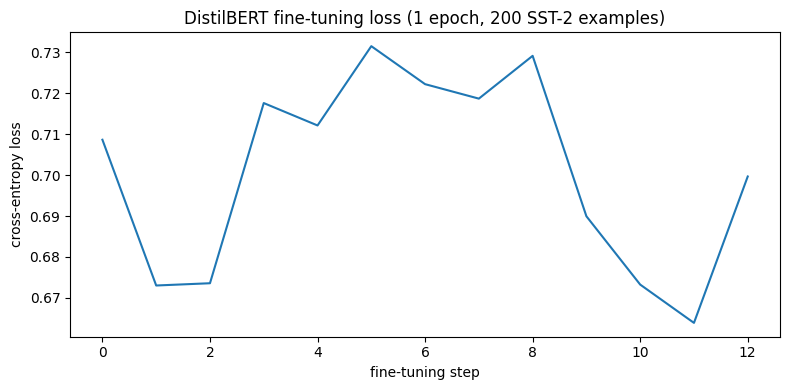

In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_enc, batch_size=16, shuffle=True)
val_loader = DataLoader(val_enc, batch_size=16)

optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

bert_model.train()
finetune_losses = []
for step, batch in enumerate(train_loader):
    outputs = bert_model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        labels=batch["labels"],
    )
    loss = outputs.loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    finetune_losses.append(loss.item())

print(f"fine-tuning steps: {len(finetune_losses)}")
print(f"first-step loss: {finetune_losses[0]:.4f}, last-step loss: {finetune_losses[-1]:.4f}")

bert_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch in val_loader:
        outputs = bert_model(
            input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]
        )
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == batch["labels"]).sum().item()
        total += batch["labels"].size(0)

print(f"validation accuracy after {len(finetune_losses)} fine-tuning steps: {correct/total:.1%} ({correct}/{total})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(finetune_losses)
ax.set_xlabel("fine-tuning step")
ax.set_ylabel("cross-entropy loss")
ax.set_title("DistilBERT fine-tuning loss (1 epoch, 200 SST-2 examples)")
plt.tight_layout()
plt.show()

## 10. Conclusion and Further Reading <a id="conclusion"></a>

**Key insights:**

- The from-scratch NumPy multi-head attention matches PyTorch's
  `nn.MultiheadAttention` to within numerical tolerance, confirming the
  shapes and scaling from the theory notebook carry over exactly into the
  trained model.
- A full encoder-decoder transformer with causal masking and cross-attention
  learns the sequence-reversal task from teacher forcing alone; the
  cross-attention heatmap shows the anti-diagonal pattern the task's
  structure predicts.
- Beam search can recover sequences that greedy decoding misses by keeping
  multiple hypotheses alive, scored in log-probability space.
- BLEU is the wrong metric for a task with one deterministic correct answer;
  choosing the metric that matches the task's actual structure (exact-match
  and token accuracy here) matters as much as choosing the right model.
- Pre-training (masked language modeling) produces reusable feature
  representations; fine-tuning a small task-specific head on top of a
  pre-trained transformer needs far fewer labeled examples and far less
  compute than training the same architecture from scratch, because most of
  "how language works" is already encoded in the pre-trained weights.

### Further Reading

- Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS.
- Devlin, J. et al. (2019). *BERT: Pre-training of Deep Bidirectional
  Transformers for Language Understanding*. NAACL.
- Sanh, V. et al. (2019). *DistilBERT, a distilled version of BERT*. NeurIPS
  EMC^2 Workshop.
- PyTorch documentation: `torch.nn.Transformer`, `torch.nn.MultiheadAttention`.
- Hugging Face `transformers` and `datasets` documentation and tutorials.